In [2]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv('china_ai_growth_dataset_2010_2026.csv')

In [ ]:
#print the dataset
df.convert_dtypes(convert_string=True)

In [ ]:
#Question: What is the historical "decoupling" point between AI Research (Publications) and AI Commercialization (Patents)?
#create a linegraph to show the growth of AI patents and publications over time
fig, ax = plt.subplots(figsize=(10, 6))


df.plot(x='Year', y=['AI Patents Share (%)', 'AI Publication Share (%)'], 
        kind='line', marker='o', ax=ax, color=['#1f77b4', 'orange'])


ax.set_title('AI Patents and Publication Share Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('Percentage (%)') 
ax.grid(True)


plt.show()


In [ ]:
#Question 2: Does Government spending act as a "Catalyst" or a "Safety Net" for Private Investment?
#crete a scatter plot to show the relationship between government spending and private investment in AI, and add a line of best fit to show the correlation
import numpy as np 

plt.figure(figsize=(8, 6))
plt.scatter(df['Government AI Spending In Billions(USD)'], df['Private AI Investment In Billions(USD)'], color='black')

x = df['Government AI Spending In Billions(USD)']
y = df['Private AI Investment In Billions(USD)']
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='red', label='Correlation Line')

correlation_matrix = np.corrcoef(df['Government AI Spending In Billions(USD)'], df['Private AI Investment In Billions(USD)'])
r_value = correlation_matrix[0, 1]
r_squared = (r_value ** 2) * 100
print(f'Coefficient of Determination (R²): {r_squared:.4f}%')

plt.title('Government AI Spending vs Private AI Investment')
plt.xlabel('Government AI Spending (Billion USD)')
plt.ylabel('Private AI Investment (Billion USD)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#Question 3: Which factor is the strongest predictor of the AI_Growth_Rate (%)?
from sklearn.linear_model import LinearRegression
#linear regression model to predict AI Growth Rate based on R&D Expenditure, AI Investment, and AI Startups Count
X = df[['R&D Expenditure (% of GDP)', 'Private AI Investment In Billions(USD)', 'AI Startups Count']]
Y = df['AI Growth Rate (%)']
model = LinearRegression()
model.fit(X, Y)
coefficients = model.coef_
feature_names = X.columns
for feature, coef in zip(feature_names, coefficients):
    print(f'{feature}: {coef:.4f}')

names = feature_names
values = coefficients

plt.figure(figsize=(10, 5))
colors = ['green' if x > 0 else 'red' for x in values]
plt.barh(names, values, color=colors)
plt.title('Impact Strength on AI Growth Rate')
plt.xlabel('Coefficient Value')
plt.axvline(0, color='black', lw=1) 
plt.show()

Year: 2027, Projected AI Companies Count: 5620, Projected AI Total Publications: 173868
Year: 2028, Projected AI Companies Count: 5899, Projected AI Total Publications: 188216
Year: 2029, Projected AI Companies Count: 6177, Projected AI Total Publications: 203127


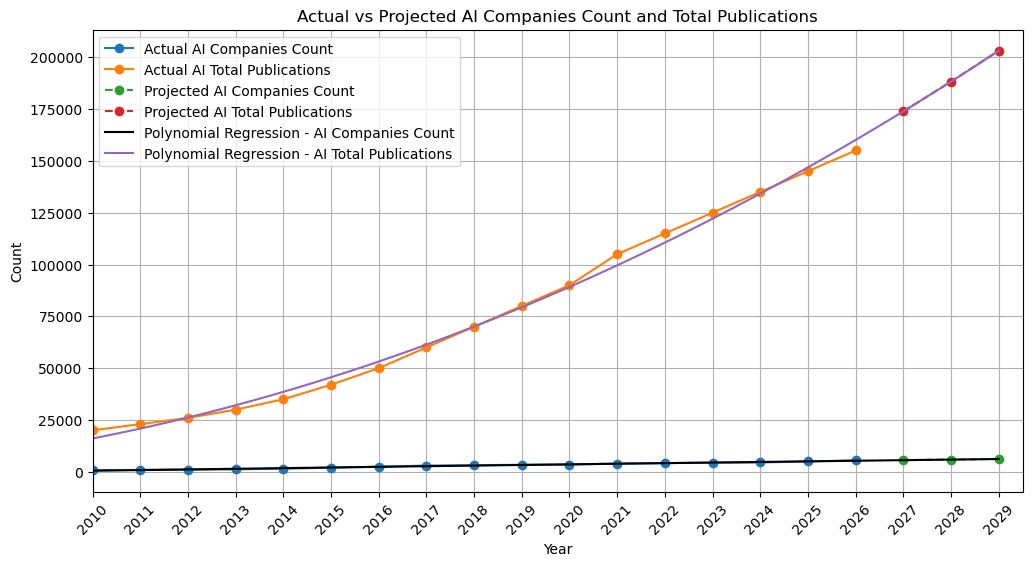

In [12]:
#Question 4: Based on current trajectories, what is the projected AI_Companies_Count and AI Total Publications for the next 3 years?
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

X = df['Year'].values.reshape(-1, 1)

y_companies = df['AI Companies Count'].values
y_publications = df['AI Total Publications'].values

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

model_companies = LinearRegression()
model_companies.fit(X_poly, y_companies)

model_publications = LinearRegression()
model_publications.fit(X_poly, y_publications)

future_years = np.array([2027, 2028, 2029]).reshape(-1, 1)
future_years_poly = poly.transform(future_years)

predicted_companies = model_companies.predict(future_years_poly)
predicted_publications = model_publications.predict(future_years_poly)

for year, companies, publications in zip(future_years.flatten(), predicted_companies, predicted_publications):
    print(f'Year: {year}, Projected AI Companies Count: {companies:.0f}, Projected AI Total Publications: {publications:.0f}')
#show the line and polynomial regression lines for both AI Companies Count and AI Total Publications, 
#and also show the actual data points for both AI Companies Count and AI Total Publications, 
# with the x-axis showing the years from 2010 to 2029, and the y-axis showing the count for both AI Companies and AI Total Publications. 
# Also, make sure to include a legend to differentiate between actual and projected values, and add grid lines for better readability.

X_smooth = np.linspace(2010, 2029, 100).reshape(-1, 1)
X_smooth_poly = poly.transform(X_smooth)
curve_companies = model_companies.predict(X_smooth_poly)
curve_publications = model_publications.predict(X_smooth_poly)

plt.figure(figsize=(12, 6))
plt.plot(df['Year'], df['AI Companies Count'], marker='o', label='Actual AI Companies Count')
plt.plot(df['Year'], df['AI Total Publications'], marker='o', label='Actual AI Total Publications')
plt.plot(future_years, predicted_companies, marker='o', linestyle='--', label='Projected AI Companies Count')
plt.plot(future_years, predicted_publications, marker='o', linestyle='--', label='Projected AI Total Publications')
plt.plot(X_smooth, curve_companies, color='black',linestyle='-', label='Polynomial Regression - AI Companies Count')
plt.plot(X_smooth, curve_publications, linestyle='-', label='Polynomial Regression - AI Total Publications')

all_years = np.arange(df['Year'].min(), 2030, 1) 
plt.xticks(all_years, rotation=45)
plt.xlim(df['Year'].min(), 2029.5)

plt.title('Actual vs Projected AI Companies Count and Total Publications')

plt.xlabel('Year')
plt.ylabel('Count')

plt.legend()
plt.grid(True)

plt.show()
